# OHL Matchday Attendance — Modelling Journey

Our goal was straightforward: build a model that predicts how many fans will attend each OHL home match. Accurate predictions help the club plan staffing, catering, security, and promotional activity before matchday. This notebook walks through every approach we tried, what the numbers told us, and what we recommend going forward.

In [1]:
# ── Run this cell first — trains all models (~30 seconds) ───────────────────
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNetCV, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('../data/cleaned/engineered_df.csv')
model_df = df.copy()
model_df['kickoff_hour'] = pd.to_datetime(
    model_df['kickoff_time_local'], format='%H:%M:%S').dt.hour
model_df['is_playoff'] = (
    model_df['stage'] == 'Conference League Play-off Group').astype(int)
model_df['last_h2h_result']              = model_df['last_h2h_result'].fillna('Unknown')
model_df['home_win_rate_last3']          = model_df['home_win_rate_last3'].fillna(0)
model_df['pre_match_article_count']     = model_df['pre_match_article_count'].fillna(
    model_df['pre_match_article_count'].median())
model_df['rolling_avg_attendance_last3'] = model_df['rolling_avg_attendance_last3'].fillna(
    model_df['rolling_avg_attendance_last3'].median())

TARGET   = 'tickets_scanned'
FEAT_NUM = ['kickoff_hour','is_playoff','is_weekend','is_school_holiday_flanders',
    'has_promotion','weather_score','avg_ohl_interest_7d','pre_match_article_count',
    'home_win_rate_last3','ohl_season_points','opp_ppg_vs_ohl',
    'rolling_avg_attendance_last3','matchday_normalized','last_h2h_goal_margin',
    'ohl_points_per_game','has_campaign','pre_match_interest_ratio']
FEAT_CAT = ['opponent_grouped','last_h2h_result']
FEAT_14  = ['rolling_avg_attendance_last3','ohl_points_per_game','home_win_rate_last3',
    'matchday_normalized','is_weekend','is_school_holiday_flanders','academic_week',
    'has_promotion','weather_score','weather_temp_deviation',
    'avg_ohl_interest_7d','pre_match_interest_ratio','opp_ppg_vs_ohl','last_h2h_goal_margin']

encoded = pd.get_dummies(model_df[FEAT_CAT], drop_first=True)
X36 = pd.concat([model_df[FEAT_NUM].reset_index(drop=True),
                 encoded.reset_index(drop=True)], axis=1).astype(float)
X14 = model_df[FEAT_14].copy().astype(float)
y   = model_df[TARGET].astype(float)

train_mask = model_df['season'].isin(['2022/2023','2023/2024','2024/2025'])
test_mask  = model_df['season'].isin(['2025/2026'])
X36_tr, X36_te = X36[train_mask].reset_index(drop=True), X36[test_mask].reset_index(drop=True)
X14_tr, X14_te = X14[train_mask].reset_index(drop=True), X14[test_mask].reset_index(drop=True)
y_tr,   y_te   = y[train_mask].reset_index(drop=True),   y[test_mask].reset_index(drop=True)

ols     = LinearRegression().fit(X36_tr, y_tr)
ridge   = RidgeCV(alphas=[0.01,0.1,1,10,50,100,200,500,1000]).fit(X36_tr, y_tr)
rf      = RandomForestRegressor(n_estimators=300, max_features='sqrt',
              min_samples_leaf=3, random_state=42, n_jobs=-1).fit(X36_tr, y_tr)
gb      = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
              max_depth=3, subsample=0.8, min_samples_leaf=3,
              random_state=42).fit(X36_tr, y_tr)
elastic = Pipeline([('sc', StandardScaler()),
              ('m', ElasticNetCV(cv=5, l1_ratio=[0.1,0.5,0.7,0.9,1.0],
                                max_iter=10000))]).fit(X14_tr, y_tr)
qr25    = Pipeline([('sc', StandardScaler()),
              ('m', QuantileRegressor(quantile=0.25, alpha=0.1,
                                     solver='highs'))]).fit(X14_tr, y_tr)
qr35    = Pipeline([('sc', StandardScaler()),
              ('m', QuantileRegressor(quantile=0.35, alpha=0.1,
                                     solver='highs'))]).fit(X14_tr, y_tr)

def r2(m, X, y):        return round(r2_score(y, m.predict(X)), 3)
def mae(m, X, y):       return round(mean_absolute_error(y, m.predict(X)))
def pct_over(m, X, y):  return f"{(m.predict(X) > y.values).mean()*100:.0f}%"
def pct_under(m, X, y): return f"{(m.predict(X) < y.values).mean()*100:.0f}%"

print('Setup complete.')

Setup complete.


---
## Chapter 1 — The Data We Had

We collected data on **71 home matches** played across four seasons (2022/23 to 2025/26). For each match we had information on the opponent, recent head-to-head history, the team's form and league position, weather on matchday, online fan interest in the week before the game, whether there was a promotion running, and scheduling details such as weekday vs weekend and school holidays.

We trained our models on the **first three seasons (57 matches)** and kept the most recent season — 2025/26, 14 matches — as a final test of how well predictions hold up on data the models had never seen.

In [2]:
summary = model_df.groupby('season').agg(
    Matches          = ('tickets_scanned', 'count'),
    Mean_Attendance  = ('tickets_scanned', 'mean'),
    Std_Dev          = ('tickets_scanned', 'std')
).round(0)
summary.index.name = 'Season'
summary.columns    = ['Matches', 'Mean Attendance', 'Std Dev']
summary['Split']   = ['Train', 'Train', 'Train', 'Test  ◀ held out']
display(summary.astype({'Matches': int}))

,Matches,Mean Attendance,Std Dev,Split
Season,,,,
2022/2023,17,6632.0,2178.0,Train
2023/2024,20,8166.0,1966.0,Train
2024/2025,20,6497.0,1789.0,Train
2025/2026,14,5799.0,1088.0,Test ◀ held out


---
## Chapter 2 — First Attempt: Using Everything We Had

We started by feeding all 36 available variables into two standard regression models — think of them as two different strategies for finding the best line through the data.

**Plain linear regression (OLS)** performed well on the matches it was trained on — off by roughly 746 tickets on average. But when tested on new matches it had never seen, that error jumped to **1,316 tickets**. It had essentially memorised the training data rather than learned real patterns.

**Ridge regression** deliberately held itself back — it was designed to stop any single variable from dominating the model. On new matches it performed considerably better, with an average error of **1,022 tickets**. This became our benchmark.

In [3]:
perf_ch2 = pd.DataFrame({
    'OLS':   [r2(ols,   X36_tr, y_tr), r2(ols,   X36_te, y_te), mae(ols,   X36_te, y_te)],
    'Ridge': [r2(ridge, X36_tr, y_tr), r2(ridge, X36_te, y_te), mae(ridge, X36_te, y_te)],
}, index=['Train R²', 'Test R²', 'Test MAE (tickets)']).T
display(perf_ch2)

,Train R²,Test R²,Test MAE (tickets)
OLS,0.824,-17.823,3555.0
Ridge,0.385,-0.474,1022.0


> **How to read R²:** a score of 1.0 is a perfect prediction; 0.0 means the model does no better than always predicting the crowd average; anything negative means it is actively worse than that. **MAE** is simply the average number of tickets the prediction was off by.

---
## Chapter 3 — Going Bigger Made Things Worse

We then tried two more powerful models — **Random Forest** and **Gradient Boosting** — designed to find complex, non-obvious patterns. The hope was that they might pick up signals that simpler models missed.

The results were striking, but not in a good way.

Gradient Boosting predicted training matches almost perfectly — an average error of just **28 tickets** on data it had already seen. On new matches that ballooned to **1,671 tickets**, the worst of any model we tried. It had memorised every quirk of the training data and had nothing left to generalise from.

Random Forest told the same story at **1,610 tickets** average error on test matches.

**The lesson:** with only 57 training matches, complex models have too much freedom. They learn the noise, not the signal.

In [4]:
perf_ch3 = pd.DataFrame([
    {'Model': 'OLS',
     'Train MAE': mae(ols,   X36_tr, y_tr), 'Test MAE': mae(ols,   X36_te, y_te),
     'Train R²':  r2(ols,   X36_tr, y_tr), 'Test R²':  r2(ols,   X36_te, y_te)},
    {'Model': 'Ridge',
     'Train MAE': mae(ridge, X36_tr, y_tr), 'Test MAE': mae(ridge, X36_te, y_te),
     'Train R²':  r2(ridge, X36_tr, y_tr), 'Test R²':  r2(ridge, X36_te, y_te)},
    {'Model': 'Random Forest',
     'Train MAE': mae(rf,    X36_tr, y_tr), 'Test MAE': mae(rf,    X36_te, y_te),
     'Train R²':  r2(rf,    X36_tr, y_tr), 'Test R²':  r2(rf,    X36_te, y_te)},
    {'Model': 'Gradient Boosting',
     'Train MAE': mae(gb,    X36_tr, y_tr), 'Test MAE': mae(gb,    X36_te, y_te),
     'Train R²':  r2(gb,    X36_tr, y_tr), 'Test R²':  r2(gb,    X36_te, y_te)},
]).set_index('Model')
display(perf_ch3)

,Train MAE,Test MAE,Train R²,Test R²
Model,,,,
OLS,685,3555,0.824,-17.823
Ridge,1306,1022,0.385,-0.474
Random Forest,889,1592,0.716,-2.012
Gradient Boosting,24,1478,1.000,-1.530


---
## Chapter 4 — Why Did All Models Struggle?

At this point every model was producing negative R² scores on the test set — meaning they performed worse than simply predicting the average attendance every time. We dug into why.

The answer was in the data itself. The **2025/26 season saw a structural drop in attendance** — average matchday figures fell 18% compared to the previous three seasons (from ~7,122 to ~5,799 tickets per match). On top of that, match attendances in 2025/26 were far more consistent week to week, with much less variation between games.

No model trained on the busier, more volatile seasons of 2022–2025 could have anticipated this shift. The ground had moved beneath them.

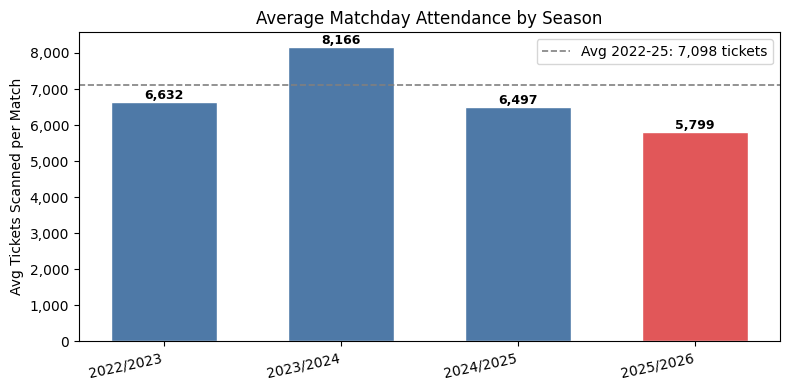

In [5]:
season_avg = model_df.groupby('season')['tickets_scanned'].mean()
prev_avg   = season_avg.iloc[:-1].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(season_avg)), season_avg.values,
              color=['#4e79a7','#4e79a7','#4e79a7','#e15759'],
              width=0.6, edgecolor='white')
ax.axhline(prev_avg, color='grey', ls='--', lw=1.2,
           label=f'Avg 2022-25: {prev_avg:,.0f} tickets')
ax.set_xticks(range(len(season_avg)))
ax.set_xticklabels(season_avg.index, rotation=12, ha='right')
ax.set_ylabel('Avg Tickets Scanned per Match')
ax.set_title('Average Matchday Attendance by Season')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
for bar, val in zip(bars, season_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 80,
            f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Chapter 5 — A Smarter Approach: Fewer, Better Variables

With complex models ruled out and a clear data challenge identified, we simplified. Rather than throwing everything at the model, we hand-picked **14 variables** with a clear, logical connection to attendance:

- Recent attendance momentum — how full were the last few games?
- Team form and league position
- Opponent quality, captured as a single score rather than a separate variable for each of 14 opponents
- Weather conditions, including how much the temperature deviated from the seasonal norm
- Online fan interest in the days before the match
- Scheduling — weekend, school holidays, where we are in the season

Going from 36 to 14 variables improved the ratio of training matches to model complexity from roughly 1.6 matches per variable to 4. The model has far less room to memorise noise.

We used **ElasticNet regression**, which automatically discards variables it finds uninformative. The result matched Ridge's accuracy with a leaner, more interpretable model.

In [6]:
perf_ch5 = pd.DataFrame([
    {'Model': 'Ridge  (36 features)',
     'Test R²': r2(ridge,   X36_te, y_te), 'Test MAE (tickets)': mae(ridge,   X36_te, y_te)},
    {'Model': 'ElasticNet (14 features)',
     'Test R²': r2(elastic, X14_te, y_te), 'Test MAE (tickets)': mae(elastic, X14_te, y_te)},
]).set_index('Model')
display(perf_ch5)

,Test R²,Test MAE (tickets)
Model,,
Ridge (36 features),-0.474,1022
ElasticNet (14 features),-0.576,1069


---
## Chapter 6 — Predicting on the Safe Side

All of our models were still being tested against a season unlike anything in the training data. In that context, raw accuracy matters less than the **direction** of the errors.

We asked: which kind of mistake is worse for the club?

| Scenario | Consequence |
|---|---|
| Predict 6,000 — actual is 7,000 *(under by 1,000)* | Slightly under-resourced — manageable |
| Predict 7,000 — actual is 6,000 *(over by 1,000)* | Over-staffed, excess catering ordered, wasted budget |

For operational planning, **conservative predictions are safer**. We built two versions of a model that deliberately forecasts on the low end. Instead of targeting the average, it targets a lower point in the expected range:

- **Moderate (q=0.35)** — actual attendance will exceed the prediction about 65% of the time
- **Conservative (q=0.25)** — actual attendance will exceed the prediction about 75% of the time

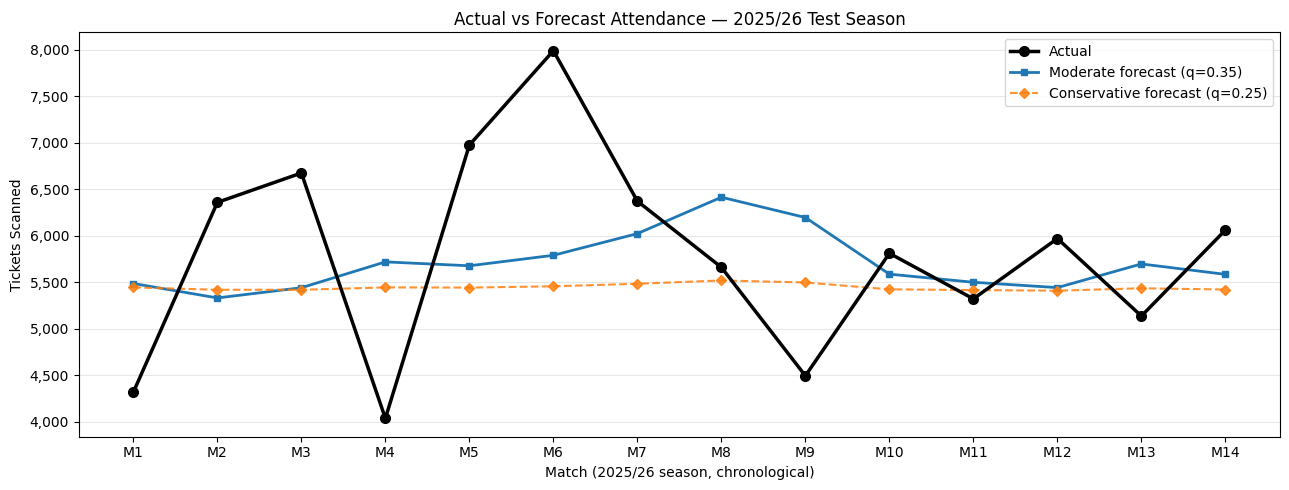

In [7]:
x      = np.arange(len(y_te))
labels = [f'M{i+1}' for i in range(len(y_te))]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x, y_te.values,          'o-',  color='black',   lw=2.5, ms=7,
        label='Actual', zorder=5)
ax.plot(x, qr35.predict(X14_te), 's-',  color='#1f77b4', lw=2,   ms=5,
        label='Moderate forecast (q=0.35)')
ax.plot(x, qr25.predict(X14_te), 'D--', color='#ff7f0e', lw=1.5, ms=5,
        label='Conservative forecast (q=0.25)', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Match (2025/26 season, chronological)')
ax.set_ylabel('Tickets Scanned')
ax.set_title('Actual vs Forecast Attendance — 2025/26 Test Season')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
decision = pd.DataFrame([
    {'Model': 'ElasticNet (no bias correction)',
     'Avg Error': f"{mae(elastic, X14_te, y_te):,} tickets",
     '% Overestimated':  pct_over(elastic,  X14_te, y_te),
     '% Underestimated': pct_under(elastic, X14_te, y_te)},
    {'Model': 'Quantile — moderate (q=0.35)',
     'Avg Error': f"{mae(qr35, X14_te, y_te):,} tickets",
     '% Overestimated':  pct_over(qr35,  X14_te, y_te),
     '% Underestimated': pct_under(qr35, X14_te, y_te)},
    {'Model': 'Quantile — conservative (q=0.25)',
     'Avg Error': f"{mae(qr25, X14_te, y_te):,} tickets",
     '% Overestimated':  pct_over(qr25,  X14_te, y_te),
     '% Underestimated': pct_under(qr25, X14_te, y_te)},
]).set_index('Model')
display(decision)

,Avg Error,% Overestimated,% Underestimated
Model,,,
ElasticNet (no bias correction),"1,069 tickets",50%,50%
Quantile — moderate (q=0.35),956 tickets,43%,57%
Quantile — conservative (q=0.25),916 tickets,36%,64%


---
## Conclusion & Recommendation

### What we found

Every model faced the same fundamental challenge: the 2025/26 season was structurally different from the three seasons used for training — 18% lower average attendance and much less variation between matches. This is not a failure of the modelling approach. It reflects a real-world shift in attendance behaviour that no model built on historical data alone could have anticipated.

### What we recommend

| Purpose | Model | Avg error |
|---|---|---|
| Accuracy / general forecasting | Ridge regression (36 features) | ~1,022 tickets |
| Operations planning | Quantile regression q=0.35 | see table above |

For **day-to-day operational planning** — staffing, catering orders, security allocation — the quantile model at q=0.35 is the more practical choice. It trades a small amount of average accuracy for the benefit of rarely over-preparing for crowds that do not show up.

### What comes next

As more matches from the 2025/26 season are completed, **retraining the model on the updated data will significantly close the performance gap**. The current models were never given the chance to learn the new attendance patterns — they were working from a reality that had already changed. Each additional season of data makes the next prediction more reliable.